# HAI Walkthrough Notebook

This notebook is designed to support **deficiency D035** for the dissertation. It works one full end-to-end example on the balanced HAI turbine-loop case `attack_p2 (a1)`:

1. fit the raw lag-expanded sparse baseline,
2. run a train-only threshold-alignment pilot,
3. choose the workflow branch,
4. run anytime compression under the dissertation's strict default policy,
5. and state the final deployment artifact.

The point is operational clarity rather than new science. The notebook shows what `raw baseline -> diagnostic -> rectify -> compress or stop` looks like on one real dataset already discussed in the manuscript.


## Walkthrough Scope

The walkthrough uses the HAI `a1` subset because it is the cleanest real-data case in the dissertation for the complete pipeline:

- Chapter 5 already uses it as a positive real-data rectification example.
- Chapter 7 already shows that it also supports deployment-eligible compression.
- The resulting path is therefore the most useful worked example for the Chapter 4 workflow.

This notebook assumes the same dedicated `cutlass` kernel used by the other study notebooks in this repository.


In [1]:
from __future__ import annotations

# Standard-library imports are kept explicit here because this notebook
# is meant to be read as an operational walkthrough, not just executed.
# A reader should be able to see immediately which modules are used for:
# 1. environment / module control,
# 2. data handling,
# 3. plotting,
# 4. baseline fitting,
# 5. notebook-friendly display.
import importlib
import json
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler as SkStandardScaler

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import Markdown, display
except Exception:
    Markdown = None
    display = None

# The raw and rectified sparse fits both use iterative solvers, and the
# walkthrough is not about solver-warning forensics. Suppressing these
# warnings keeps the notebook focused on the workflow decisions.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# When the notebook is re-run in an interactive session, `cutlass` may
# already be imported from a previous state. Clearing it first ensures
# that the walkthrough always reflects the currently installed package.
for module_name in [name for name in list(sys.modules) if name == "cutlass" or name.startswith("cutlass.")]:
    del sys.modules[module_name]

# Pull the specific `cutlass` primitives used by the dissertation
# pipeline. Keeping these aliases local makes the later analysis cells
# easier to read.
cutlass = importlib.import_module("cutlass")
Rectifier = cutlass.Rectifier
DuplicateColumnConsolidator = cutlass.DuplicateColumnConsolidator
CutlassLogisticCV = cutlass.CutlassLogisticCV
calculate_youden_j = cutlass.calculate_youden_j

# Set notebook-wide plotting defaults once so later cells can focus on
# the analysis rather than repeated style boilerplate.
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
if sns is not None:
    sns.set(style="whitegrid")


In [2]:
def _find_repo_root() -> Path:
    # The notebook may be executed from the repo root, the notebook
    # directory, or an exported script context. Search upward from the
    # current working directory (and `__file__` when available) until
    # the dissertation repo layout is found.
    anchors = [Path.cwd().resolve()]
    if "__file__" in globals():
        anchors.insert(0, Path(__file__).resolve().parent)
    for anchor in anchors:
        for candidate in (anchor, *anchor.parents):
            if (candidate / "scripts").is_dir() and (candidate / "notebooks").is_dir():
                return candidate
    raise FileNotFoundError("Could not locate the dissertation repository root.")


REPO_ROOT = _find_repo_root()
NOTEBOOKS_DIR = REPO_ROOT / "notebooks"
PROCESSED_DIR = NOTEBOOKS_DIR / "processed_data"
FIGURES_DIR = NOTEBOOKS_DIR / "Figures"
RUN_DIR = NOTEBOOKS_DIR / "runs_new" / "walkthrough"

# Create output directories up front so later cells can write figures
# and summaries without worrying about path existence.
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)

# This walkthrough intentionally fixes one HAI case and one real-data
# parameter setting. The goal is not to search for the best possible
# configuration, but to show what the dissertation's default playbook
# looks like on a representative positive example.
TARGET_SPEC = {
    "domain": "HAI attack_p2 (a1)",
    "dataset_family": "HAI",
    "tag": "a1",
    "fixed_c": 0.012,
    "rectifier_kw": dict(sdfilter=None, snap=0.001, quantile_bounds=(0.35, 0.65)),
    "duplicate_mode": "within_group",
}

# These constants mirror the manuscript's default deployment policy:
# 1. allow a small training-time tolerance on J,
# 2. then require held-out non-inferiority before adoption.
STRICT_POLICY = {
    "label": "2%",
    "eps": 0.02,
    "auc_margin": 0.02,
    "j_margin": 0.02,
    "bootstrap_reps": 500,
    "bootstrap_seed": 42,
    "deployment_requirement": "both",
}

# Print the key paths and settings so a reader can quickly verify which
# dataset, outputs, and policy the walkthrough is actually using.
print("Repository root:", REPO_ROOT)
print("Run directory:", RUN_DIR)
print("Figures directory:", FIGURES_DIR)
print("Target case:", TARGET_SPEC["domain"])
print("Strict policy:", STRICT_POLICY)


Repository root: C:\Users\jason\ODU\dissertation
Run directory: C:\Users\jason\ODU\dissertation\notebooks\runs_new\walkthrough
Figures directory: C:\Users\jason\ODU\dissertation\notebooks\Figures
Target case: HAI attack_p2 (a1)
Strict policy: {'label': '2%', 'eps': 0.02, 'auc_margin': 0.02, 'j_margin': 0.02, 'bootstrap_reps': 500, 'bootstrap_seed': 42, 'deployment_requirement': 'both'}


In [3]:
def render_markdown(text: str) -> None:
    # Prefer rich notebook rendering when available, but keep a plain
    # print fallback so the same code also works if executed as a script.
    if Markdown is not None and display is not None:
        display(Markdown(text))
    else:
        print(text)


def format_numeric(value: float, digits: int = 3) -> str:
    # Centralize display formatting so the narrative cells stay readable
    # and all reported numbers use the same precision policy.
    if pd.isna(value):
        return "n/a"
    return f"{float(value):.{digits}f}"


def best_youden_threshold(prob, y_true) -> tuple[float, float]:
    # The workflow repeatedly needs an explicit operating threshold.
    # Rather than assume 0.5 is always appropriate, search the finite
    # set of score breakpoints and keep the threshold that maximizes J.
    prob_arr = np.asarray(prob, dtype=float)
    y_arr = np.asarray(y_true).astype(int)
    values = np.unique(np.sort(prob_arr))
    if values.size == 0:
        return 0.5, 0.0
    mids = 0.5 * (values[:-1] + values[1:]) if values.size > 1 else np.asarray([], dtype=float)
    thresholds = np.r_[values[0] - 1e-9, mids, values[-1] + 1e-9]
    best_j = -np.inf
    best_thr = float(thresholds[0])
    for thr in thresholds:
        pred = (prob_arr >= thr).astype(int)
        j = float(calculate_youden_j(y_arr, pred))
        if j > best_j:
            best_j = j
            best_thr = float(thr)
    return best_thr, float(best_j)


def metric_row(y_true, prob, *, threshold: float = 0.5) -> dict:
    # Keep the metric bundle small and operational:
    # - AUC captures ranking quality,
    # - J captures thresholded operating quality,
    # - TPR/TNR make it obvious whether improvements come from recall,
    #   specificity, or both.
    y_arr = np.asarray(y_true).astype(int)
    prob_arr = np.asarray(prob, dtype=float)
    pred = (prob_arr >= threshold).astype(int)
    positives = y_arr == 1
    negatives = y_arr == 0
    tp = int(np.sum((pred == 1) & positives))
    tn = int(np.sum((pred == 0) & negatives))
    fp = int(np.sum((pred == 1) & negatives))
    fn = int(np.sum((pred == 0) & positives))
    tpr = tp / max(int(np.sum(positives)), 1)
    tnr = tn / max(int(np.sum(negatives)), 1)
    return {
        "auc": float(roc_auc_score(y_arr, prob_arr)),
        "j": float(calculate_youden_j(y_arr, pred)),
        "threshold": float(threshold),
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tpr": float(tpr),
        "tnr": float(tnr),
    }


def bootstrap_delta_ci(
    y_true,
    baseline_prob,
    baseline_pred,
    rule_prob,
    rule_pred,
    *,
    reps: int,
    seed: int,
) -> tuple[tuple[float, float], tuple[float, float]]:
    # This is the held-out adoption gate used by the workflow. The
    # bootstrap is paired because the compressed rule and its baseline
    # are evaluated on the same test examples.
    y_arr = np.asarray(y_true).astype(int)
    base_prob_arr = np.asarray(baseline_prob, dtype=float)
    base_pred_arr = np.asarray(baseline_pred).astype(int)
    rule_prob_arr = np.asarray(rule_prob, dtype=float)
    rule_pred_arr = np.asarray(rule_pred).astype(int)
    rng = np.random.default_rng(seed)
    auc_deltas = []
    j_deltas = []
    n = len(y_arr)
    for _ in range(int(reps)):
        idx = rng.integers(0, n, n)
        y_boot = y_arr[idx]
        # Skip degenerate bootstrap draws that contain only one class,
        # because AUC is undefined in that case.
        if np.unique(y_boot).size < 2:
            continue
        auc_deltas.append(
            float(roc_auc_score(y_boot, rule_prob_arr[idx]) - roc_auc_score(y_boot, base_prob_arr[idx]))
        )
        j_deltas.append(
            float(calculate_youden_j(y_boot, rule_pred_arr[idx]) - calculate_youden_j(y_boot, base_pred_arr[idx]))
        )
    if not auc_deltas:
        return (float("nan"), float("nan")), (float("nan"), float("nan"))
    auc_ci = tuple(np.quantile(np.asarray(auc_deltas, dtype=float), [0.025, 0.975]).tolist())
    j_ci = tuple(np.quantile(np.asarray(j_deltas, dtype=float), [0.025, 0.975]).tolist())
    return auc_ci, j_ci


def strict_policy_deployment_decision(
    auc_noninferior: bool,
    j_noninferior: bool,
    *,
    requirement: str,
) -> bool:
    # The notebook exposes the policy as a small explicit decision
    # function so the adoption logic is auditable rather than implicit.
    if requirement == "both":
        return bool(auc_noninferior and j_noninferior)
    if requirement == "auc_only":
        return bool(auc_noninferior)
    if requirement == "j_only":
        return bool(j_noninferior)
    if requirement == "either":
        return bool(auc_noninferior or j_noninferior)
    raise ValueError(f"Unsupported deployment requirement: {requirement}")


def subsystem_label(feature_name: str) -> str:
    # HAI feature names encode plant blocks such as P1, P2, P3, P4.
    # Extracting that label lets the walkthrough summarize whether the
    # sparse model concentrates weight on the attacked subsystem.
    match = re.search(r"(P\d)", str(feature_name))
    return match.group(1) if match else "Other"


def summarize_subsystem_mass(coef: pd.Series, *, stage: str) -> pd.DataFrame:
    # Aggregate absolute coefficient mass by subsystem. This is a simple
    # proxy for attribution concentration that is easy to explain in a
    # walkthrough notebook.
    coef_nz = coef[coef != 0].copy()
    if coef_nz.empty:
        return pd.DataFrame(
            [{"stage": stage, "subsystem": "Other", "nonzero_features": 0, "abs_weight": 0.0, "share_of_abs_weight": 0.0}]
        )
    rows = []
    total_abs = float(coef_nz.abs().sum())
    for subsystem, part in coef_nz.groupby(lambda name: subsystem_label(str(name))):
        rows.append(
            {
                "stage": stage,
                "subsystem": subsystem,
                "nonzero_features": int(len(part)),
                "abs_weight": float(part.abs().sum()),
                "share_of_abs_weight": float(part.abs().sum() / max(total_abs, 1e-12)),
            }
        )
    return pd.DataFrame(rows).sort_values(["stage", "share_of_abs_weight"], ascending=[True, False])


def top_nonzero_features(coef: pd.Series, *, k: int = 12) -> pd.DataFrame:
    # Produce a compact ranked table of the strongest retained features.
    # This is useful both for interpretation and for sanity-checking
    # that the walkthrough is selecting plausible variables.
    coef_nz = coef[coef != 0].copy()
    if coef_nz.empty:
        return pd.DataFrame(columns=["rank", "feature", "coefficient", "abs_coefficient"])
    coef_nz = coef_nz.reindex(coef_nz.abs().sort_values(ascending=False).index)
    rows = []
    for rank, (feature, value) in enumerate(coef_nz.iloc[: min(k, len(coef_nz))].items(), start=1):
        rows.append(
            {
                "rank": rank,
                "feature": str(feature),
                "coefficient": float(value),
                "abs_coefficient": float(abs(value)),
            }
        )
    return pd.DataFrame(rows)


In [4]:
def load_hai_case(tag: str) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    # The walkthrough uses the prebuilt balanced parquet outputs so it
    # can focus on model decisions instead of repeating the upstream HAI
    # CSV-to-window conversion logic.
    train_path = PROCESSED_DIR / f"train_{tag}_sm_hai.parquet"
    test_path = PROCESSED_DIR / f"test_{tag}_sm_hai.parquet"
    if not train_path.exists() or not test_path.exists():
        raise FileNotFoundError(
            "Balanced HAI parquet files are missing. Run notebooks/build_hai_cutlass_data.py first."
        )
    train_df = pd.read_parquet(train_path)
    test_df = pd.read_parquet(test_path)
    return (
        train_df.drop(columns=["INDC"]),
        train_df["INDC"].astype(int),
        test_df.drop(columns=["INDC"]),
        test_df["INDC"].astype(int),
    )


def prepare_cutlass_rectified_design(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    *,
    rectifier_kw: dict,
    duplicate_mode: str = "within_group",
) -> dict:
    # This helper packages the dissertation's representation-first path:
    # 1. fit a rectifier on training data only,
    # 2. transform train and test,
    # 3. consolidate duplicate logical columns before sparse fitting.
    rectifier = Rectifier(groups=None, **rectifier_kw)
    X_train_rect = rectifier.fit_transform(X_train, y_train)
    X_test_rect = rectifier.transform(X_test)
    consolidator = DuplicateColumnConsolidator(mode=duplicate_mode, expansion="split_evenly")
    X_train_fit = consolidator.fit_transform(X_train_rect, feature_names=rectifier.feature_names_)
    X_test_fit = consolidator.transform(X_test_rect, feature_names=rectifier.feature_names_)
    return {
        "rectifier": rectifier,
        "consolidator": consolidator,
        "X_train_fit": np.asarray(X_train_fit, dtype=float),
        "X_test_fit": np.asarray(X_test_fit, dtype=float),
        "rectified_feature_names": list(rectifier.feature_names_),
        "fit_feature_names": list(consolidator.feature_names_),
    }


def expanded_cutlass_coefficients(design: dict, coef_fit: np.ndarray) -> pd.Series:
    # The sparse model is fit in the consolidated feature space, but the
    # walkthrough wants to report coefficients back in the expanded
    # logical-feature space so the selected conditions are easier to read.
    coef_fit_series = pd.Series(np.asarray(coef_fit).ravel(), index=design["fit_feature_names"], name="coef")
    coef_full = design["consolidator"].expand_coefficients(coef_fit_series)
    return pd.Series(np.asarray(coef_full).ravel(), index=design["rectified_feature_names"], name="coef")


def fit_cutlass_raw_fixed_l1(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    *,
    fixed_c: float,
    max_iter: int = 6000,
    tol: float = 1e-4,
) -> dict:
    # Raw baseline = standardized lag-expanded inputs + fixed L1
    # logistic regression. This is the "start here" branch in the
    # workflow because it represents the conventional sparse baseline.
    scaler = SkStandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    lr = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=float(fixed_c),
        max_iter=max_iter,
        tol=tol,
        random_state=42,
    )
    lr.fit(X_train_scaled, y_train)
    prob = lr.predict_proba(X_test_scaled)[:, 1]
    coef = pd.Series(lr.coef_.ravel(), index=X_train.columns, name="coef")
    return {
        "coef": coef,
        "prob": prob,
        "model": lr,
        "metrics": {
            **metric_row(y_test, prob, threshold=0.5),
            "nonzero_total": int((coef != 0).sum()),
            "chosen_C": float(fixed_c),
        },
    }


def fit_cutlass_rectified_fixed_l1(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    y_test: np.ndarray,
    *,
    fixed_c: float,
    rectifier_kw: dict,
    duplicate_mode: str,
    max_iter: int = 12000,
    tol: float = 1e-4,
) -> dict:
    # Rectified pilot = same sparse model family, but on the
    # representation produced by the rectifier + duplicate consolidation
    # path. Keeping the downstream model fixed isolates the effect of the
    # representation change itself.
    design = prepare_cutlass_rectified_design(
        X_train,
        y_train,
        X_test,
        rectifier_kw=rectifier_kw,
        duplicate_mode=duplicate_mode,
    )
    lr = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=float(fixed_c),
        max_iter=max_iter,
        tol=tol,
        random_state=42,
    )
    lr.fit(design["X_train_fit"], y_train)
    prob = lr.predict_proba(design["X_test_fit"])[:, 1]
    coef_fit = pd.Series(lr.coef_.ravel(), index=design["fit_feature_names"], name="coef")
    coef_full = expanded_cutlass_coefficients(design, lr.coef_)
    return {
        "coef_fit": coef_fit,
        "coef": coef_full,
        "prob": prob,
        "model": lr,
        "design": design,
        "metrics": {
            **metric_row(y_test, prob, threshold=0.5),
            "nonzero_total": int((coef_full != 0).sum()),
            "fit_nonzero_total": int((coef_fit != 0).sum()),
            "rectified_features": int(len(design["rectified_feature_names"])),
            "fit_features": int(len(design["fit_feature_names"])),
            "chosen_C": float(fixed_c),
        },
    }


In [5]:
def sigmoid(score) -> np.ndarray:
    # Convert logic-polish scores into pseudo-probabilities so the
    # walkthrough can evaluate AUC on compressed rule candidates.
    score_arr = np.asarray(score, dtype=float)
    return 1.0 / (1.0 + np.exp(-np.clip(score_arr, -40.0, 40.0)))


def fit_cutlass_model(
    X_train_fit: np.ndarray,
    y_train: pd.Series,
    *,
    fixed_c: float,
    logic_polish: bool,
):
    # This helper wraps the `cutlass` model used for the rectified
    # baseline and the logic-polished compression path. Most options are
    # frozen because the notebook is documenting the standard workflow,
    # not running a tuning study.
    model = CutlassLogisticCV(
        Cs=[float(fixed_c)],
        penalty="l1",
        solver="cd",
        scoring="neg_log_loss",
        cv=3,
        n_jobs=1,
        tol=1e-4,
        max_iter=2000,
        refit=True,
        random_state=42,
        verbose=False,
        cv_rule="min",
        logic_polish=logic_polish,
        logic_scale=10.0,
        logic_rel_tol=0.02,
        logic_plot=False,
        logic_k_policy="global",
        logic_intercept="maxj",
    )
    model.fit(X_train_fit, np.asarray(y_train, dtype=int))
    return model


def summarize_baseline(
    baseline_model,
    X_train_fit: np.ndarray,
    y_train: pd.Series,
    X_test_fit: np.ndarray,
    y_test: pd.Series,
) -> dict:
    # The sparse rectified baseline is evaluated at the threshold chosen
    # on the training split, then carried unchanged to test. This keeps
    # the comparison aligned with the workflow's train-only principle.
    prob_train = baseline_model.predict_proba(X_train_fit)[:, 1]
    threshold_train, j_train = best_youden_threshold(prob_train, y_train)
    prob_test = baseline_model.predict_proba(X_test_fit)[:, 1]
    pred_test = (prob_test >= threshold_train).astype(int)
    coef_fit = np.asarray(baseline_model.coef_, dtype=float).ravel()
    return {
        "coef_fit": coef_fit,
        "threshold_train": float(threshold_train),
        "j_train": float(j_train),
        "prob_test": prob_test,
        "pred_test": pred_test,
        "auc_test": float(roc_auc_score(np.asarray(y_test).astype(int), prob_test)),
        "j_test": float(calculate_youden_j(np.asarray(y_test).astype(int), pred_test)),
        "nonzero_total": int(np.sum(np.abs(coef_fit) > 0)),
    }


def score_rule_candidates(
    X_train_fit: np.ndarray,
    y_train: pd.Series,
    X_test_fit: np.ndarray,
    y_test: pd.Series,
    coef_fit: np.ndarray,
    logic_diag: dict,
) -> tuple[pd.DataFrame, dict[int, dict[str, np.ndarray]]]:
    # `logic_diag_` contains the anytime path: a global ordering of
    # signed logical conditions plus the intercepts needed to score each
    # prefix length k. This function turns that internal object into an
    # auditable frontier table.
    coef_arr = np.asarray(coef_fit, dtype=float).ravel()
    order = np.asarray(logic_diag["order"], dtype=int)
    b_k = np.asarray(logic_diag["b_k"], dtype=float)
    k_used = len(order)
    K = float(logic_diag["K_used"])

    # The logic path ranks conditions by signed contribution. Applying
    # the coefficient sign before cumulative summation means later
    # prefixes are formed in the same orientation used by polishing.
    signs = np.sign(coef_arr[order])
    signs[signs == 0] = 1.0
    X_train_sel = X_train_fit[:, order] * signs
    X_test_sel = X_test_fit[:, order] * signs
    train_cum = np.cumsum(X_train_sel, axis=1)
    test_cum = np.cumsum(X_test_sel, axis=1)
    y_train_arr = np.asarray(y_train).astype(int)
    y_test_arr = np.asarray(y_test).astype(int)

    rows = []
    prediction_cache: dict[int, dict[str, np.ndarray]] = {}
    for idx in range(k_used):
        # Each prefix k is treated as a candidate deployment rule. The
        # frontier stores both train-J (selection side) and held-out
        # metrics (validation side).
        k = idx + 1
        train_score = K * train_cum[:, idx] + b_k[idx]
        test_score = K * test_cum[:, idx] + b_k[idx]
        train_pred = (train_score >= 0.0).astype(int)
        test_pred = (test_score >= 0.0).astype(int)
        test_prob = sigmoid(test_score)
        rows.append(
            {
                "k": k,
                "train_j": float(calculate_youden_j(y_train_arr, train_pred)),
                "test_j": float(calculate_youden_j(y_test_arr, test_pred)),
                "test_auc": float(roc_auc_score(y_test_arr, test_prob)),
            }
        )
        prediction_cache[k] = {
            "test_prob": test_prob,
            "test_pred": test_pred,
            "threshold_in_signed_sum": float(-b_k[idx] / max(K, 1e-12)),
        }
    return pd.DataFrame(rows), prediction_cache


def select_strict_policy_row(
    frontier_df: pd.DataFrame,
    baseline_summary: dict,
    *,
    eps: float,
) -> dict:
    # The dissertation's default selection rule is intentionally simple:
    # choose the smallest prefix whose training J remains within an
    # epsilon tolerance of the rectified sparse baseline.
    baseline_train_j = float(baseline_summary["j_train"])
    baseline_test_j = float(baseline_summary["j_test"])
    baseline_test_auc = float(baseline_summary["auc_test"])
    baseline_nonzero = int(baseline_summary["nonzero_total"])
    train_threshold = (1.0 - float(eps)) * baseline_train_j
    eligible = frontier_df.loc[frontier_df["train_j"] >= train_threshold].copy()
    if len(eligible):
        # Smallest passing prefix = most conservative compression that
        # still satisfies the declared training-side tolerance.
        chosen = eligible.sort_values("k").iloc[0]
        meets_train_tolerance = True
    else:
        # Fallback only if no prefix passes the tolerance at all.
        chosen = frontier_df.sort_values("train_j", ascending=False).iloc[0]
        meets_train_tolerance = False
    k_selected = int(chosen["k"])
    return {
        "eps": float(eps),
        "k_selected": k_selected,
        "meets_train_tolerance": bool(meets_train_tolerance),
        "baseline_nonzero": baseline_nonzero,
        "compression_ratio": float(baseline_nonzero / max(k_selected, 1)),
        "baseline_auc_test": baseline_test_auc,
        "rule_auc_test": float(chosen["test_auc"]),
        "delta_auc": float(chosen["test_auc"] - baseline_test_auc),
        "baseline_j_test": baseline_test_j,
        "rule_j_test": float(chosen["test_j"]),
        "delta_j": float(chosen["test_j"] - baseline_test_j),
        "baseline_j_train": baseline_train_j,
        "rule_j_train": float(chosen["train_j"]),
        "train_tolerance_floor": float(train_threshold),
    }


def selected_rule_table(
    logic_diag: dict,
    feature_names: list[str],
    coef_fit: np.ndarray,
    *,
    k_selected: int,
) -> pd.DataFrame:
    # Build a readable table for the final compressed rule: rank,
    # feature, coefficient direction, and subsystem location. This turns
    # the abstract frontier decision into a concrete deployable artifact.
    coef_arr = np.asarray(coef_fit, dtype=float).ravel()
    order = np.asarray(logic_diag["order"], dtype=int)[:k_selected]
    rows = []
    for rank, idx in enumerate(order, start=1):
        coef_value = float(coef_arr[idx])
        rows.append(
            {
                "rank": rank,
                "feature": str(feature_names[idx]),
                "signed_direction": "+" if coef_value >= 0 else "-",
                "coefficient": coef_value,
                "abs_coefficient": float(abs(coef_value)),
                "subsystem": subsystem_label(str(feature_names[idx])),
            }
        )
    return pd.DataFrame(rows)


## 1. Load the HAI Walkthrough Case

The notebook uses the balanced HAI `a1` split because the walkthrough is about the **decision path**, not class-imbalance engineering. The same train/test split is kept for every branch comparison.


In [6]:
# Load the single real-data case used by the walkthrough.
X_train, y_train, X_test, y_test = load_hai_case(TARGET_SPEC["tag"])

# Record the split sizes because they are part of the operational
# context for the later branch and deployment decisions.
data_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": int(len(y_train)),
            "positives": int(y_train.sum()),
            "negatives": int((1 - y_train).sum()),
            "features": int(X_train.shape[1]),
        },
        {
            "split": "test",
            "rows": int(len(y_test)),
            "positives": int(y_test.sum()),
            "negatives": int((1 - y_test).sum()),
            "features": int(X_test.shape[1]),
        },
    ]
)
data_summary.to_csv(RUN_DIR / "hai_a1_walkthrough_data_summary.csv", index=False)

# Show the loaded case so the notebook's starting point is explicit.
print("Loaded walkthrough case:", TARGET_SPEC["domain"])
display(data_summary) if display is not None else print(data_summary)


Loaded walkthrough case: HAI attack_p2 (a1)


,split,rows,positives,negatives,features
0,train,2552,1276,1276,590
1,test,1080,540,540,590


## 2. Raw Baseline and Threshold-Alignment Diagnostic

Chapter 4 says to start with the raw lag-expanded sparse baseline, then ask whether a train-only rectified pilot preserves discrimination while improving attribution behavior or deployment usability.

The comparison below keeps the split fixed, keeps the penalty fixed, and changes only the representation.


c:\Users\jason\.conda\envs\cutlass\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\jason\.conda\envs\cutlass\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\jason\.conda\envs\cutlass\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf inste

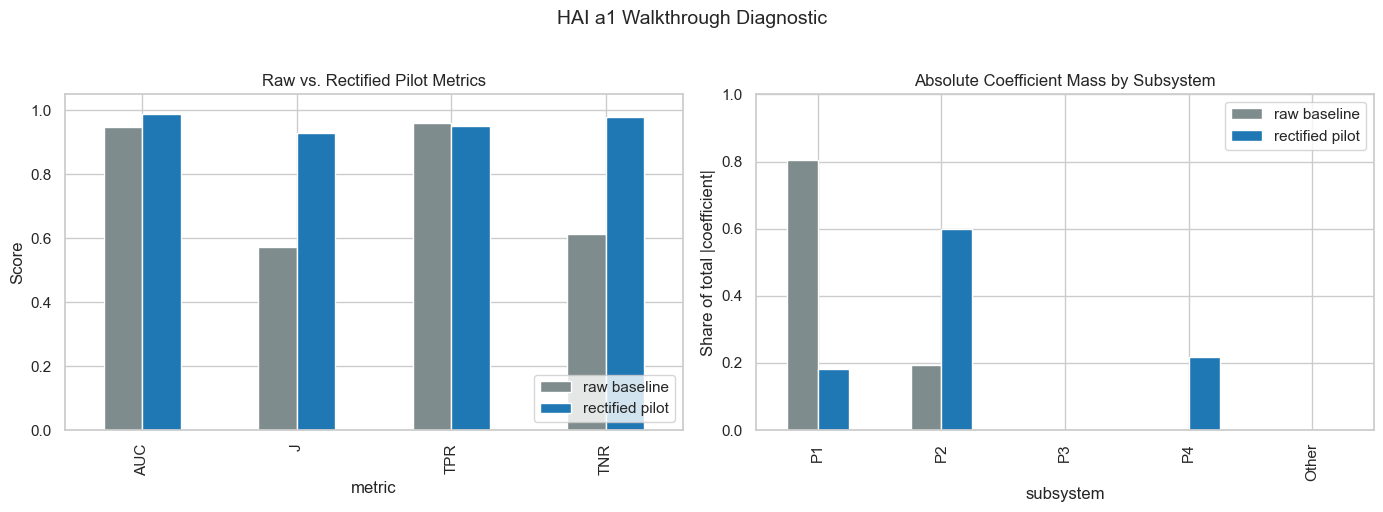

,stage,auc,j,tpr,tnr,nonzero_total,threshold,fit_nonzero_total,rectified_features,fit_features
0,raw baseline,0.949228,0.574074,0.961111,0.612963,26,0.5,NaN,NaN,NaN
1,rectified pilot,0.989491,0.929630,0.950000,0.979630,57,0.5,39.0,590.0,459.0


,rank,feature,coefficient,abs_coefficient
0,1,P2_VYT02_06,-0.279691,0.279691
1,2,P2_VYT02_07,-0.267123,0.267123
2,3,P2_VYT02_04,-0.265646,0.265646
3,4,P2_VYT02_05,-0.253757,0.253757
4,5,P2_VYT02_03,-0.203684,0.203684
5,6,P2_VYT02_02,-0.190371,0.190371
6,7,P4_ST_PT01_07,0.189028,0.189028
7,8,P2_VYT02_09,-0.181842,0.181842
8,9,P2_VYT02_01,-0.175696,0.175696
9,10,P2_VYT02_08,-0.168604,0.168604


### Diagnostic Readout
- Raw baseline test AUC = **0.949**, J = **0.574**, TNR = **0.613** at threshold 0.5.
- Rectified pilot test AUC = **0.989**, J = **0.930**, TNR = **0.980** on the same split and penalty.
- P2 coefficient-mass share rises from **0.194** to **0.599**, which is the desired direction for a turbine-loop attack case.

In [7]:
# Step 1 of the workflow: fit the conventional raw sparse baseline.
raw_result = fit_cutlass_raw_fixed_l1(
    X_train,
    y_train.to_numpy(),
    X_test,
    y_test.to_numpy(),
    fixed_c=TARGET_SPEC["fixed_c"],
)
# Step 2 of the workflow: fit the train-only rectified pilot using the
# same split and penalty so the representation change is isolated.
rect_result = fit_cutlass_rectified_fixed_l1(
    X_train,
    y_train.to_numpy(),
    X_test,
    y_test.to_numpy(),
    fixed_c=TARGET_SPEC["fixed_c"],
    rectifier_kw=TARGET_SPEC["rectifier_kw"],
    duplicate_mode=TARGET_SPEC["duplicate_mode"],
)

# Package the headline metrics side-by-side for the raw-vs-rectified
# diagnostic that drives the branch decision.
pilot_summary = pd.DataFrame(
    [
        {
            "stage": "raw baseline",
            "auc": raw_result["metrics"]["auc"],
            "j": raw_result["metrics"]["j"],
            "tpr": raw_result["metrics"]["tpr"],
            "tnr": raw_result["metrics"]["tnr"],
            "nonzero_total": raw_result["metrics"]["nonzero_total"],
            "threshold": raw_result["metrics"]["threshold"],
        },
        {
            "stage": "rectified pilot",
            "auc": rect_result["metrics"]["auc"],
            "j": rect_result["metrics"]["j"],
            "tpr": rect_result["metrics"]["tpr"],
            "tnr": rect_result["metrics"]["tnr"],
            "nonzero_total": rect_result["metrics"]["nonzero_total"],
            "fit_nonzero_total": rect_result["metrics"]["fit_nonzero_total"],
            "threshold": rect_result["metrics"]["threshold"],
            "rectified_features": rect_result["metrics"]["rectified_features"],
            "fit_features": rect_result["metrics"]["fit_features"],
        },
    ]
)
pilot_summary.to_csv(RUN_DIR / "hai_a1_walkthrough_pilot_summary.csv", index=False)

# Summarize attribution concentration by subsystem so the walkthrough
# can say something operational about *where* the sparse model focuses.
raw_subsystem = summarize_subsystem_mass(raw_result["coef"], stage="raw baseline")
rect_subsystem = summarize_subsystem_mass(rect_result["coef"], stage="rectified pilot")
subsystem_summary = pd.concat([raw_subsystem, rect_subsystem], ignore_index=True)
subsystem_summary.to_csv(RUN_DIR / "hai_a1_walkthrough_subsystem_summary.csv", index=False)

# Capture the strongest retained features for quick inspection.
raw_top = top_nonzero_features(raw_result["coef"], k=12)
rect_top = top_nonzero_features(rect_result["coef"], k=12)
raw_top.to_csv(RUN_DIR / "hai_a1_walkthrough_raw_top_features.csv", index=False)
rect_top.to_csv(RUN_DIR / "hai_a1_walkthrough_rectified_top_features.csv", index=False)

# Pull out the P2 share explicitly because this is the attacked turbine
# block and therefore the most interpretable concentration summary.
raw_p2_share = float(
    raw_subsystem.loc[raw_subsystem["subsystem"] == "P2", "share_of_abs_weight"].iloc[0]
) if (raw_subsystem["subsystem"] == "P2").any() else 0.0
rect_p2_share = float(
    rect_subsystem.loc[rect_subsystem["subsystem"] == "P2", "share_of_abs_weight"].iloc[0]
) if (rect_subsystem["subsystem"] == "P2").any() else 0.0

# Build narrow display tables for the figure panel below.
pilot_compare = pd.DataFrame(
    [
        {"metric": "AUC", "raw baseline": raw_result["metrics"]["auc"], "rectified pilot": rect_result["metrics"]["auc"]},
        {"metric": "J", "raw baseline": raw_result["metrics"]["j"], "rectified pilot": rect_result["metrics"]["j"]},
        {"metric": "TPR", "raw baseline": raw_result["metrics"]["tpr"], "rectified pilot": rect_result["metrics"]["tpr"]},
        {"metric": "TNR", "raw baseline": raw_result["metrics"]["tnr"], "rectified pilot": rect_result["metrics"]["tnr"]},
    ]
)

subsystem_compare = subsystem_summary.pivot(
    index="subsystem",
    columns="stage",
    values="share_of_abs_weight",
).fillna(0.0).reindex(["P1", "P2", "P3", "P4", "Other"]).fillna(0.0)

# Visualize both the operating metrics and the subsystem concentration
# shift, because the workflow cares about both prediction and structure.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pilot_compare.set_index("metric").plot(kind="bar", ax=axes[0], color=["#7f8c8d", "#1f77b4"])
axes[0].set_ylim(0.0, 1.05)
axes[0].set_title("Raw vs. Rectified Pilot Metrics")
axes[0].set_ylabel("Score")
axes[0].legend(loc="lower right")

subsystem_compare.plot(kind="bar", ax=axes[1], color=["#7f8c8d", "#1f77b4"])
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title("Absolute Coefficient Mass by Subsystem")
axes[1].set_ylabel("Share of total |coefficient|")
axes[1].legend(loc="upper right")

fig.suptitle("HAI a1 Walkthrough Diagnostic", fontsize=14, y=1.02)
fig.tight_layout()
pilot_figure_path = FIGURES_DIR / "walkthrough_hai_a1_pilot_diagnostic.png"
fig.savefig(pilot_figure_path, dpi=160, bbox_inches="tight")
plt.show()

# Show the summary tables so the branch decision is inspectable.
display(pilot_summary) if display is not None else print(pilot_summary)
display(rect_top) if display is not None else print(rect_top)

# Render a concise narrative so the diagnostic result is obvious even if
# a reader only skims the notebook outputs.
render_markdown(
    "### Diagnostic Readout\n"
    f"- Raw baseline test AUC = **{format_numeric(raw_result['metrics']['auc'])}**, "
    f"J = **{format_numeric(raw_result['metrics']['j'])}**, "
    f"TNR = **{format_numeric(raw_result['metrics']['tnr'])}** at threshold 0.5.\n"
    f"- Rectified pilot test AUC = **{format_numeric(rect_result['metrics']['auc'])}**, "
    f"J = **{format_numeric(rect_result['metrics']['j'])}**, "
    f"TNR = **{format_numeric(rect_result['metrics']['tnr'])}** on the same split and penalty.\n"
    f"- P2 coefficient-mass share rises from **{format_numeric(raw_p2_share)}** to **{format_numeric(rect_p2_share)}**, "
    "which is the desired direction for a turbine-loop attack case."
)


## 3. Workflow Branch Decision

The Chapter 4 workflow says to switch from raw to rectified features when a train-only pilot preserves held-out discrimination and improves support concentration, lag localization, or compactness.


In [8]:
# The branch rule below mirrors the manuscript's operational logic:
# switch to rectification when it does not materially hurt ranking,
# improves thresholded behavior, and concentrates attribution more
# plausibly on the attacked subsystem.
rectify_supported = bool(
    rect_result["metrics"]["auc"] >= raw_result["metrics"]["auc"] - STRICT_POLICY["auc_margin"]
    and rect_result["metrics"]["j"] > raw_result["metrics"]["j"]
    and rect_p2_share >= raw_p2_share
)
chosen_branch = "rectify" if rectify_supported else "stay raw / hybrid"

# Save the key diagnostic quantities so the notebook leaves behind a
# small machine-readable branch-decision artifact.
branch_summary = {
    "domain": TARGET_SPEC["domain"],
    "chosen_branch": chosen_branch,
    "rectify_supported": rectify_supported,
    "raw_auc": float(raw_result["metrics"]["auc"]),
    "rectified_auc": float(rect_result["metrics"]["auc"]),
    "raw_j": float(raw_result["metrics"]["j"]),
    "rectified_j": float(rect_result["metrics"]["j"]),
    "raw_p2_share": float(raw_p2_share),
    "rectified_p2_share": float(rect_p2_share),
}
(RUN_DIR / "hai_a1_walkthrough_branch_summary.json").write_text(
    json.dumps(branch_summary, indent=2),
    encoding="utf-8",
)

# State the branch in prose because this is the central decision that
# the Chapter 4 workflow asks the analyst to make.
render_markdown(
    "### Branch Decision\n"
    f"- Chosen branch: **{chosen_branch}**.\n"
    "- Reason: the rectified pilot keeps or improves discrimination and materially improves the operating-point behavior and subsystem concentration.\n"
    "- Operational interpretation: this dataset is aligned enough with threshold-mediated structure to promote the rectified sparse fit to the new baseline."
)


### Branch Decision
- Chosen branch: **rectify**.
- Reason: the rectified pilot keeps or improves discrimination and materially improves the operating-point behavior and subsystem concentration.
- Operational interpretation: this dataset is aligned enough with threshold-mediated structure to promote the rectified sparse fit to the new baseline.

## 4. Compression Stage Under the Dissertation's Strict Default Policy

Because the rectified pilot wins, the workflow proceeds to the optional compression phase. The strict default policy used here matches the Chapter 4 operational rule:

- choose the smallest prefix satisfying `J_train(k) >= 0.98 * J_train,base`,
- then require held-out bootstrap lower bounds `ΔAUC > -0.02` and `ΔJ > -0.02`
  before treating the compressed rule as deployment-eligible.


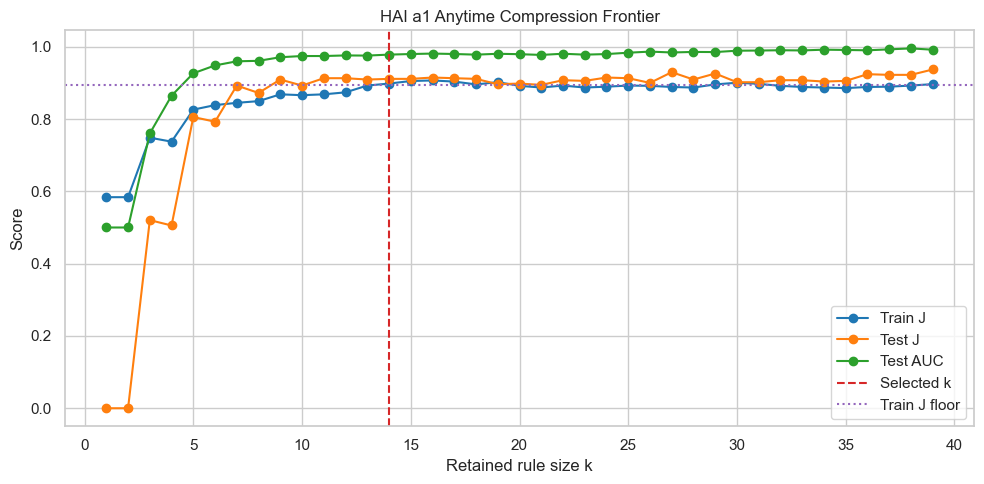

,eps,k_selected,meets_train_tolerance,baseline_nonzero,compression_ratio,baseline_auc_test,rule_auc_test,delta_auc,baseline_j_test,rule_j_test,...,baseline_j_train,rule_j_train,train_tolerance_floor,auc_ci_low,auc_ci_high,auc_noninferior,j_ci_low,j_ci_high,j_noninferior,deployment_recommendation
0,0.02,14,True,39,2.785714,0.989467,0.978224,-0.011243,0.896296,0.911111,...,0.913793,0.898119,0.895517,-0.016258,-0.006425,True,-0.005251,0.035704,True,True


,rank,feature,signed_direction,coefficient,abs_coefficient,subsystem
0,1,P1_B3005_01,+,0.432499,0.432499,P1
1,2,P2_SD01_01,+,0.378304,0.378304,P2
2,3,P2_VYT02_06,-,-0.279662,0.279662,P2
3,4,P2_VYT02_07,-,-0.267102,0.267102,P2
4,5,P2_VYT02_04,-,-0.265669,0.265669,P2
5,6,P2_VYT02_05,-,-0.253786,0.253786,P2
6,7,P2_VYT02_03,-,-0.203664,0.203664,P2
7,8,P2_VYT02_02,-,-0.190357,0.190357,P2
8,9,P4_ST_PT01_07,+,0.189626,0.189626,P4
9,10,P2_VYT02_09,-,-0.181798,0.181798,P2


In [9]:
# Once rectification wins, the rectified sparse fit becomes the new
# baseline for the compression stage.
compression_design = rect_result["design"]
baseline_model = fit_cutlass_model(
    compression_design["X_train_fit"],
    y_train,
    fixed_c=TARGET_SPEC["fixed_c"],
    logic_polish=False,
)
# The logic-polished model provides the anytime ordering used to define
# candidate compressed rules of size k = 1, 2, ..., K.
logic_model = fit_cutlass_model(
    compression_design["X_train_fit"],
    y_train,
    fixed_c=TARGET_SPEC["fixed_c"],
    logic_polish=True,
)

# Evaluate the upstream rectified sparse baseline using a train-chosen
# threshold. This is the object every compressed candidate must beat or
# nearly match under the deployment policy.
baseline_summary = summarize_baseline(
    baseline_model,
    compression_design["X_train_fit"],
    y_train,
    compression_design["X_test_fit"],
    y_test,
)
# Score the full anytime frontier so the notebook can separate:
# - training-side selection,
# - held-out validation,
# - final deployment recommendation.
frontier_df, prediction_cache = score_rule_candidates(
    compression_design["X_train_fit"],
    y_train,
    compression_design["X_test_fit"],
    y_test,
    baseline_summary["coef_fit"],
    logic_model.logic_diag_,
)
frontier_df.to_csv(RUN_DIR / "hai_a1_walkthrough_frontier.csv", index=False)

# Apply the dissertation's strict selection rule to pick the smallest
# acceptable prefix length.
strict_row = select_strict_policy_row(
    frontier_df,
    baseline_summary,
    eps=STRICT_POLICY["eps"],
)
strict_pred = prediction_cache[int(strict_row["k_selected"])]
# Then apply the held-out non-inferiority gate. This is the critical
# difference between "compressible on training" and "deployable."
auc_ci, j_ci = bootstrap_delta_ci(
    y_test,
    baseline_summary["prob_test"],
    baseline_summary["pred_test"],
    strict_pred["test_prob"],
    strict_pred["test_pred"],
    reps=STRICT_POLICY["bootstrap_reps"],
    seed=STRICT_POLICY["bootstrap_seed"],
)
auc_noninferior = bool(auc_ci[0] > -STRICT_POLICY["auc_margin"])
j_noninferior = bool(j_ci[0] > -STRICT_POLICY["j_margin"])
deployment_recommendation = strict_policy_deployment_decision(
    auc_noninferior,
    j_noninferior,
    requirement=STRICT_POLICY["deployment_requirement"],
)

# Persist the policy outcome in tabular form for downstream reference.
deployment_summary = pd.DataFrame(
    [
        {
            **strict_row,
            "auc_ci_low": float(auc_ci[0]),
            "auc_ci_high": float(auc_ci[1]),
            "auc_noninferior": auc_noninferior,
            "j_ci_low": float(j_ci[0]),
            "j_ci_high": float(j_ci[1]),
            "j_noninferior": j_noninferior,
            "deployment_recommendation": deployment_recommendation,
        }
    ]
)
deployment_summary.to_csv(RUN_DIR / "hai_a1_walkthrough_deployment_summary.csv", index=False)

# Extract the concrete retained logical conditions behind the selected
# compressed rule so the notebook ends with an interpretable artifact.
selected_rule_df = selected_rule_table(
    logic_model.logic_diag_,
    compression_design["fit_feature_names"],
    baseline_summary["coef_fit"],
    k_selected=int(strict_row["k_selected"]),
)
selected_rule_df.to_csv(RUN_DIR / "hai_a1_walkthrough_selected_rule.csv", index=False)

# Save a compact machine-readable summary for manuscript-side reuse.
threshold_line = strict_pred["threshold_in_signed_sum"]
summary_payload = {
    "domain": TARGET_SPEC["domain"],
    "baseline_nonzero": int(strict_row["baseline_nonzero"]),
    "k_selected": int(strict_row["k_selected"]),
    "compression_ratio": float(strict_row["compression_ratio"]),
    "delta_auc": float(strict_row["delta_auc"]),
    "delta_j": float(strict_row["delta_j"]),
    "auc_ci_low": float(auc_ci[0]),
    "auc_ci_high": float(auc_ci[1]),
    "j_ci_low": float(j_ci[0]),
    "j_ci_high": float(j_ci[1]),
    "auc_noninferior": bool(auc_noninferior),
    "j_noninferior": bool(j_noninferior),
    "deployment_recommendation": bool(deployment_recommendation),
    "signed_sum_threshold": float(threshold_line),
}
(RUN_DIR / "hai_a1_walkthrough_summary.json").write_text(
    json.dumps(summary_payload, indent=2),
    encoding="utf-8",
)

# Also emit a short text takeaway file so the result can be inspected
# without opening tables or figures.
takeaway_lines = [
    f"- Raw branch loses to rectification on HAI a1: AUC {raw_result['metrics']['auc']:.3f} -> {rect_result['metrics']['auc']:.3f}, J {raw_result['metrics']['j']:.3f} -> {rect_result['metrics']['j']:.3f}.",
    f"- The strict {STRICT_POLICY['label']} compression policy selects k={int(strict_row['k_selected'])} from {int(strict_row['baseline_nonzero'])} active logical conditions (x{strict_row['compression_ratio']:.2f} compression).",
    f"- Held-out deltas are delta AUC {strict_row['delta_auc']:+.3f} and delta J {strict_row['delta_j']:+.3f}.",
    f"- Bootstrap lower bounds are AUC {auc_ci[0]:+.3f} and J {j_ci[0]:+.3f}; deployment recommendation = {deployment_recommendation}.",
]
(RUN_DIR / "hai_a1_walkthrough_takeaway.md").write_text(
    "\n".join(takeaway_lines) + "\n",
    encoding="utf-8",
)

# Plot the frontier so the selected k is visible against both the
# training tolerance floor and the held-out behavior curve.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(frontier_df["k"], frontier_df["train_j"], marker="o", label="Train J", color="#1f77b4")
ax.plot(frontier_df["k"], frontier_df["test_j"], marker="o", label="Test J", color="#ff7f0e")
ax.plot(frontier_df["k"], frontier_df["test_auc"], marker="o", label="Test AUC", color="#2ca02c")
ax.axvline(int(strict_row["k_selected"]), color="#d62728", linestyle="--", linewidth=1.5, label="Selected k")
ax.axhline(strict_row["train_tolerance_floor"], color="#9467bd", linestyle=":", linewidth=1.5, label="Train J floor")
ax.set_xlabel("Retained rule size k")
ax.set_ylabel("Score")
ax.set_title("HAI a1 Anytime Compression Frontier")
ax.legend(loc="best")
frontier_figure_path = FIGURES_DIR / "walkthrough_hai_a1_frontier.png"
fig.tight_layout()
fig.savefig(frontier_figure_path, dpi=160, bbox_inches="tight")
plt.show()

# Surface both the numeric policy table and the retained-feature table.
display(deployment_summary) if display is not None else print(deployment_summary)
display(selected_rule_df) if display is not None else print(selected_rule_df)


## 5. Final Deployment Artifact

The final output of the walkthrough is not just a frontier plot. It is a concrete deployment recommendation plus the retained logical conditions that justify that recommendation.


In [10]:
# Convert the policy outcome into the final operational artifact label.
final_artifact = "compressed rule" if deployment_recommendation else "rectified sparse baseline"
# End the walkthrough with a single compact narrative block that
# restates the entire pipeline outcome from start to finish.
render_markdown(
    "### Worked Example Result\n"
    f"- **Dataset:** {TARGET_SPEC['domain']}.\n"
    f"- **Raw baseline behavior:** AUC = **{format_numeric(raw_result['metrics']['auc'])}**, "
    f"J = **{format_numeric(raw_result['metrics']['j'])}**, "
    f"TNR = **{format_numeric(raw_result['metrics']['tnr'])}**.\n"
    f"- **Threshold-alignment diagnostic:** the rectified pilot improves AUC to **{format_numeric(rect_result['metrics']['auc'])}**, "
    f"improves J to **{format_numeric(rect_result['metrics']['j'])}**, "
    f"and increases P2 coefficient concentration from **{format_numeric(raw_p2_share)}** to **{format_numeric(rect_p2_share)}**.\n"
    f"- **Chosen branch:** **{chosen_branch}**.\n"
    f"- **Compression decision:** the strict {STRICT_POLICY['label']} policy selects **k = {int(strict_row['k_selected'])}** "
    f"from **{int(strict_row['baseline_nonzero'])}** active logical conditions "
    f"(x{strict_row['compression_ratio']:.2f} compression).\n"
    f"- **Held-out gate:** delta AUC = **{strict_row['delta_auc']:+.3f}**, delta J = **{strict_row['delta_j']:+.3f}**, "
    f"bootstrap lower bounds = (**{auc_ci[0]:+.3f}**, **{j_ci[0]:+.3f}**).\n"
    f"- **Final deployment artifact:** **{final_artifact}**."
)


### Worked Example Result
- **Dataset:** HAI attack_p2 (a1).
- **Raw baseline behavior:** AUC = **0.949**, J = **0.574**, TNR = **0.613**.
- **Threshold-alignment diagnostic:** the rectified pilot improves AUC to **0.989**, improves J to **0.930**, and increases P2 coefficient concentration from **0.194** to **0.599**.
- **Chosen branch:** **rectify**.
- **Compression decision:** the strict 2% policy selects **k = 14** from **39** active logical conditions (x2.79 compression).
- **Held-out gate:** delta AUC = **-0.011**, delta J = **+0.015**, bootstrap lower bounds = (**-0.016**, **-0.005**).
- **Final deployment artifact:** **compressed rule**.

## Artifact Summary

This notebook writes supporting walkthrough artifacts to:

- `notebooks/runs_new/walkthrough/hai_a1_walkthrough_data_summary.csv`
- `notebooks/runs_new/walkthrough/hai_a1_walkthrough_pilot_summary.csv`
- `notebooks/runs_new/walkthrough/hai_a1_walkthrough_subsystem_summary.csv`
- `notebooks/runs_new/walkthrough/hai_a1_walkthrough_frontier.csv`
- `notebooks/runs_new/walkthrough/hai_a1_walkthrough_deployment_summary.csv`
- `notebooks/runs_new/walkthrough/hai_a1_walkthrough_selected_rule.csv`
- `notebooks/runs_new/walkthrough/hai_a1_walkthrough_summary.json`
- `notebooks/runs_new/walkthrough/hai_a1_walkthrough_takeaway.md`

and figure outputs to:

- `notebooks/Figures/walkthrough_hai_a1_pilot_diagnostic.png`
- `notebooks/Figures/walkthrough_hai_a1_frontier.png`
